<a href="https://colab.research.google.com/github/FarsusDasdana/WorldCup_EloRating/blob/main/EloRating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Understanding the Elo Formula

The formula `1 / (1 + 10 ** ((rating_b - rating_a) / 400))` is a logistic function. Here is why it is designed this way:

### 1. Why use `1 / (1 + ...)`?
This structure is a **Logistic Curve**. It ensures that the result is always between **0 and 1**.
- As the denominator gets very large, the result approaches 0.
- As the denominator gets close to 1, the result approaches 1.
This is perfect for representing a **probability** (0% to 100%).

### 2. Why `(1 + 10 ** x)`?
The use of **base 10** is a convention established by Arpad Elo.
- If two teams have the same rating ($R_B - R_A = 0$), the formula becomes $1 / (1 + 10^0)$, which is $1 / (1 + 1)$, or **0.5 (50%)**. This correctly predicts that equal teams have an equal chance of winning.

### 3. Why the `400` in `(rating_b - rating_a) / 400`?
The number **400** is a scaling factor that determines the "spread" of the ratings.
- It defines that a **400-point difference** makes the stronger team **10 times** more likely to win than the weaker team ($1 / (1 + 10^{-1}) \approx 0.91$).
- If you used a smaller number (like 100), ratings would be much more volatile. If you used a larger number, ratings would move very slowly. 400 was found to be the 'sweet spot' for human performance in chess and has since been adopted by many sports.

# Elo Rating System for 2026 World Cup

This notebook demonstrates the Elo rating system, which calculates relative skill levels in zero-sum games.

In [23]:
def calculate_elo(rating_a, rating_b, result_for_a, k_factor=32, name_a="", name_b=""):
    """
    Calculates the new Elo ratings for two players/teams.

    Args:
        rating_a: Current rating of Team A
        rating_b: Current rating of Team B
        result_for_a: Result for Team A (1 for win, 0.5 for draw, 0 for loss)
        k_factor: The maximum possible adjustment per game
        name_a: Name of Team A (optional)
        name_b: Name of Team B (optional)

    Returns:
        new_rating_a: New rating for Team A
        new_rating_b: New rating for Team B
    """
    # 1. Calculate Expected Score for Team A (winning chance of team A)
    expected_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    if name_a != "":
      print(f"Winning chance of {name_a}: {expected_a:.2%}")
    else:
      print(f"Winning chance of Team A: {expected_a:.2%}")
    # 2. Calculate Expected Score for Team B (winning chance of team B)
    expected_b = 1 - expected_a
    if name_b != "":
      print(f"Winning chance of {name_b}: {expected_b:.2%}")
    else:
      print(f"Winning chance of Team B: {expected_b:.2%}")

    # 3. Update Ratings
    new_rating_a = rating_a + k_factor * (result_for_a - expected_a)
    new_rating_b = rating_b + k_factor * ((1 - result_for_a) - expected_b)

    return round(new_rating_a), round(new_rating_b)

In [27]:
# Initialize team ratings
teams = {
    'Spain': 2157,
    'Argentina': 2115,
    'France': 2063,
    'England': 2024,
    'Brazil': 1991,
    'Portugal': 1989,
    'Colombia': 1982,
    'Netherland': 1948,
    'Ecuador': 1938,
    'Germany': 1932,
    'Norway': 1914,
    'Croatia': 1912,
    'Turkey': 1911,
    'Japan': 1906,
    'Belgium': 1894,
    'Uruguay': 1892,
    'Switzerland': 1891,
    'Mexico': 1881,
    'Denmark': 1869,
    'Italy': 1869,
}

def play_match(team_a_name, team_b_name, score_a):
    rating_a = teams[team_a_name]
    rating_b = teams[team_b_name]

    new_a, new_b = calculate_elo(rating_a, rating_b, score_a, name_a=team_a_name, name_b=team_b_name)

    result_text = "Win" if score_a == 1 else "Draw" if score_a == 0.5 else "Loss"
    print(f"Match: {team_a_name} ({rating_a}) vs {team_b_name} ({rating_b}) -> {team_a_name} {result_text}")
    print(f"New Ratings: {team_a_name}: {new_a} ({new_a - rating_a:+}), {team_b_name}: {new_b} ({new_b - rating_b:+})\n")

    teams[team_a_name] = new_a
    teams[team_b_name] = new_b

print("--- Starting Tournament Demo ---\n")

# Scenario 1: Expected outcome (Higher rated France wins against Brazil)
play_match('France', 'Brazil', 1)

# Scenario 2: An upset (Lower rated Turkey wins against Portugal)
play_match('Turkey', 'Portugal', 1)

# Scenario 3: A draw between closely matched teams
play_match('Mexico', 'Turkey', 0.5)

--- Starting Tournament Demo ---

Winning chance of France: 60.22%
Winning chance of Brazil: 39.78%
Match: France (2063) vs Brazil (1991) -> France Win
New Ratings: France: 2076 (+13), Brazil: 1978 (-13)

Winning chance of Turkey: 38.96%
Winning chance of Portugal: 61.04%
Match: Turkey (1911) vs Portugal (1989) -> Turkey Win
New Ratings: Turkey: 1931 (+20), Portugal: 1969 (-20)

Winning chance of Mexico: 42.85%
Winning chance of Turkey: 57.15%
Match: Mexico (1881) vs Turkey (1931) -> Mexico Draw
New Ratings: Mexico: 1883 (+2), Turkey: 1929 (-2)



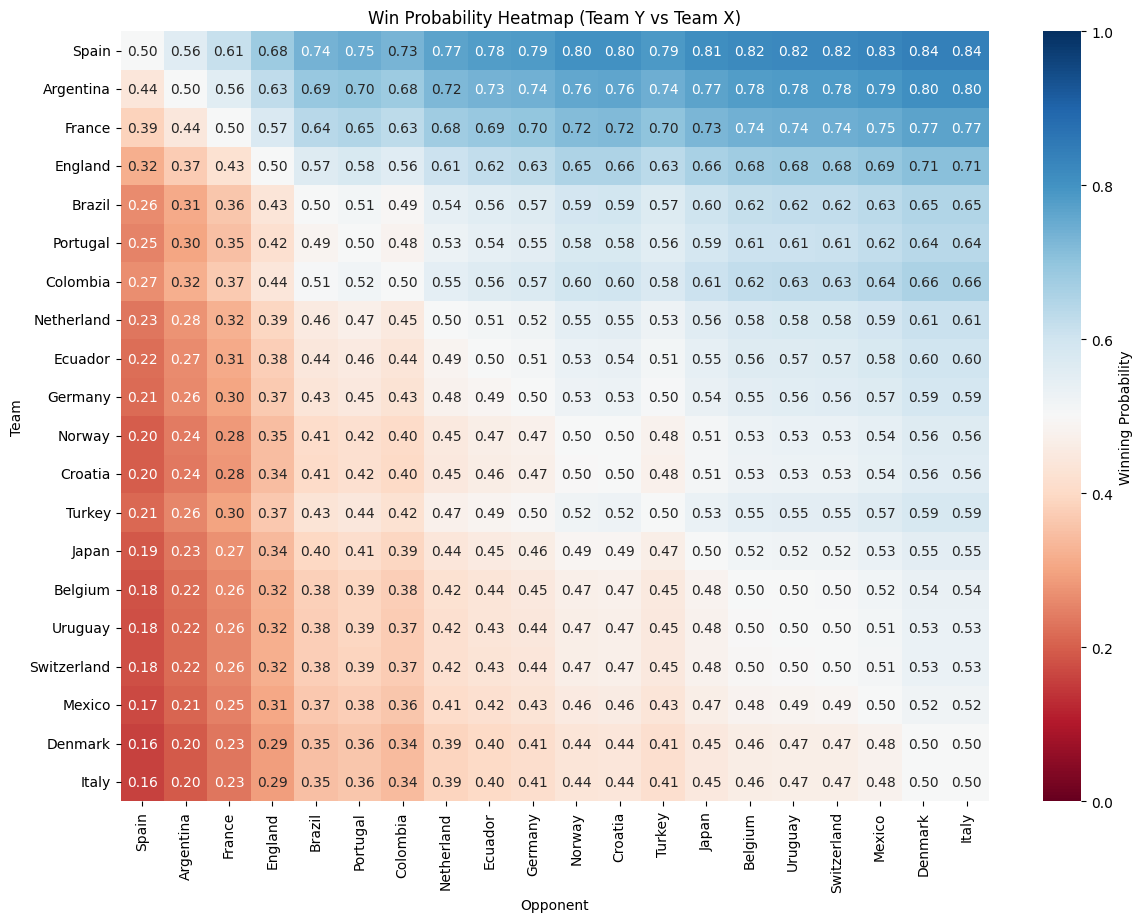

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Create a list of team names
team_names = list(teams.keys())

# Initialize a matrix for win probabilities
n = len(team_names)
prob_matrix = np.zeros((n, n))

# Calculate n-to-n cross table
for i, team_a in enumerate(team_names):
    for j, team_b in enumerate(team_names):
        ra = teams[team_a]
        rb = teams[team_b]
        # Win probability formula
        prob_matrix[i, j] = 1 / (1 + 10 ** ((rb - ra) / 400))

# Create DataFrame for better visualization
df_probs = pd.DataFrame(prob_matrix, index=team_names, columns=team_names)

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_probs,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    center=0.5,
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Winning Probability'}
)
plt.title("Win Probability Heatmap (Team Y vs Team X)")
plt.xlabel("Opponent")
plt.ylabel("Team")
plt.show()